# Proyek Pertama: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Maju

- Nama: T. Muhammad Caesar Maulana
- Email: caesarm1611@gmail.com
- Id Dicoding: caesarmaulana

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# Import libraries
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.offline as py
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import plotly.figure_factory as ff

from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import model_selection
from sklearn.metrics import roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

warnings.filterwarnings('ignore')
py.init_notebook_mode(connected=True)

## Data Understanding

### Menyiapkan data yang akan digunakan

In [2]:
# Mengunduh dataset karyawan dari sumber eksternal (GitHub)
link_dataset = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/employee/employee_data.csv'

# Membaca dataset ke dalam DataFrame menggunakan pandas
data_karyawan = pd.read_csv(link_dataset)

In [3]:
# Tampilkan 5 baris pertama dataset
data_karyawan.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [4]:
# Kondisi data
print("Info Dataset:")
data_karyawan.info()

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  

In [5]:
# Tampilkan statistik deskriptif
print("\nStatistik Deskriptif:")
data_karyawan.describe()


Statistik Deskriptif:


,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# Menelusuri setiap kolom dalam DataFrame untuk analisis awal
for nama_kolom in data_karyawan.columns:
    # Menampilkan jumlah nilai unik dari masing-masing kolom
    total_unik = data_karyawan[nama_kolom].nunique()
    print(f"{nama_kolom}: Total data unik = {total_unik}")
    print("-" * 60)


EmployeeId: Total data unik = 1470
------------------------------------------------------------
Age: Total data unik = 43
------------------------------------------------------------
Attrition: Total data unik = 2
------------------------------------------------------------
BusinessTravel: Total data unik = 3
------------------------------------------------------------
DailyRate: Total data unik = 886
------------------------------------------------------------
Department: Total data unik = 3
------------------------------------------------------------
DistanceFromHome: Total data unik = 29
------------------------------------------------------------
Education: Total data unik = 5
------------------------------------------------------------
EducationField: Total data unik = 6
------------------------------------------------------------
EmployeeCount: Total data unik = 1
------------------------------------------------------------
EnvironmentSatisfaction: Total data unik = 4
-----------

In [7]:
print("\nJumlah df per Kategori Attrition:")
print(data_karyawan['Attrition'].value_counts())


Jumlah df per Kategori Attrition:
Attrition
0.0    879
1.0    179
Name: count, dtype: int64


In [8]:
print("\nJumlah Data Null")
print(data_karyawan.isna().sum())


Jumlah Data Null
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance       

In [9]:
# Drop data dengan nilai null
data_karyawan.dropna(inplace=True)

Melihat data kategori

In [10]:
# Menyimpan nama-nama kolom bertipe object dengan nilai unik ≤ 30 ke dalam list
kolom_kategorikal = []

# Menelusuri setiap kolom dalam DataFrame
for kolom in data_karyawan.columns:
    # Mengecek apakah kolom bertipe object dan memiliki nilai unik kurang dari atau sama dengan 30
    if data_karyawan[kolom].dtype == object and len(data_karyawan[kolom].unique()) <= 30:
        kolom_kategorikal.append(kolom)  # Menambahkan ke dalam list
        print(f"{kolom} : Daftar nilai unik = {data_karyawan[kolom].unique()}")
        print("Frekuensi masing-masing nilai:")
        print(data_karyawan[kolom].value_counts())
        print("-" * 40)


BusinessTravel : Daftar nilai unik = ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Frekuensi masing-masing nilai:
BusinessTravel
Travel_Rarely        746
Travel_Frequently    205
Non-Travel           107
Name: count, dtype: int64
----------------------------------------
Department : Daftar nilai unik = ['Research & Development' 'Sales' 'Human Resources']
Frekuensi masing-masing nilai:
Department
Research & Development    701
Sales                     319
Human Resources            38
Name: count, dtype: int64
----------------------------------------
EducationField : Daftar nilai unik = ['Medical' 'Life Sciences' 'Marketing' 'Technical Degree'
 'Human Resources' 'Other']
Frekuensi masing-masing nilai:
EducationField
Life Sciences       436
Medical             330
Marketing           122
Technical Degree     96
Other                59
Human Resources      15
Name: count, dtype: int64
----------------------------------------
Gender : Daftar nilai unik = ['Female' 'Male']
Frekuensi ma

In [11]:
# Hitung jumlah kolom
len(kolom_kategorikal)

8

In [12]:
# Mengonversi semua kolom bertipe float64 menjadi int64
kolom_float = data_karyawan.select_dtypes(include='float64').columns  # Mengambil nama-nama kolom float64
data_karyawan = data_karyawan.astype({nama: 'int64' for nama in kolom_float})  # Melakukan konversi tipe data


Numerical Features


In [13]:
# Menyimpan nama kolom numerik dengan jumlah nilai unik kurang dari 30
fitur_diskrit = []

# Melakukan iterasi pada setiap kolom di DataFrame
for kolom in data_karyawan.columns:
    # Memastikan kolom bertipe numerik dan jumlah nilai uniknya < 30
    if data_karyawan[kolom].dtypes != object and data_karyawan[kolom].nunique() < 30:
        print(f"{kolom} : Daftar nilai unik = {data_karyawan[kolom].unique()}")
        fitur_diskrit.append(kolom)  # Tambahkan ke list fitur diskrit
        print("-" * 40)

# Menghapus kolom 'Attrition' jika termasuk dalam daftar fitur diskrit
if 'Attrition' in fitur_diskrit:
    fitur_diskrit.remove('Attrition')


Attrition : Daftar nilai unik = [1 0]
----------------------------------------
DistanceFromHome : Daftar nilai unik = [11  4 26  1  2 18  3 23 12  6  5 10  8 13 14  7 16 21 22  9 28 20 17 24
 25 15 27 19 29]
----------------------------------------
Education : Daftar nilai unik = [2 4 3 1 5]
----------------------------------------
EmployeeCount : Daftar nilai unik = [1]
----------------------------------------
EnvironmentSatisfaction : Daftar nilai unik = [1 3 2 4]
----------------------------------------
JobInvolvement : Daftar nilai unik = [1 3 2 4]
----------------------------------------
JobLevel : Daftar nilai unik = [2 1 4 5 3]
----------------------------------------
JobSatisfaction : Daftar nilai unik = [2 3 4 1]
----------------------------------------
NumCompaniesWorked : Daftar nilai unik = [5 9 2 1 3 0 7 4 6 8]
----------------------------------------
PercentSalaryHike : Daftar nilai unik = [15 12 14 22 13 19 11 16 17 18 20 21 24 23 25]
------------------------------------

In [14]:
# Menyusun daftar kolom numerik kontinu (nilai unik > 30)
fitur_kontinu = []

# Menelusuri setiap kolom dalam DataFrame
for kolom in data_karyawan.columns:
    # Memastikan kolom bertipe numerik dan memiliki lebih dari 30 nilai unik
    if data_karyawan[kolom].dtypes != object and data_karyawan[kolom].nunique() > 30:
        nilai_min = data_karyawan[kolom].min()
        nilai_max = data_karyawan[kolom].max()
        print(f"{kolom} : Rentang nilai = {nilai_min} s.d. {nilai_max}")
        fitur_kontinu.append(kolom)  # Tambahkan kolom ke dalam list fitur kontinu
        print("-" * 40)


EmployeeId : Rentang nilai = 2 s.d. 1470
----------------------------------------
Age : Rentang nilai = 18 s.d. 60
----------------------------------------
DailyRate : Rentang nilai = 102 s.d. 1499
----------------------------------------
HourlyRate : Rentang nilai = 30 s.d. 100
----------------------------------------
MonthlyIncome : Rentang nilai = 1009 s.d. 19999
----------------------------------------
MonthlyRate : Rentang nilai = 2094 s.d. 26999
----------------------------------------
TotalWorkingYears : Rentang nilai = 0 s.d. 40
----------------------------------------
YearsAtCompany : Rentang nilai = 0 s.d. 40
----------------------------------------


Data Visualisation

In [15]:
# Fungsi bantu untuk menyesuaikan dimensi visualisasi plot
def atur_ukuran_plot(figur, lebar=600, tinggi=400):
    # Menetapkan ukuran layout (lebar dan tinggi) untuk objek plot
    figur.update_layout(width=lebar, height=tinggi)


In [16]:
# Memisahkan data menjadi dua kelompok: keluar (attrition) dan tetap bekerja
keluar = data_karyawan[data_karyawan['Attrition'] != 0]
tetap = data_karyawan[data_karyawan['Attrition'] == 0]

# ------------ CETAK STATISTIK -----------------------
# Menghitung jumlah total data, jumlah karyawan keluar, dan yang tetap
jumlah_total = len(data_karyawan)
jumlah_keluar = len(keluar)
jumlah_tetap = len(tetap)

# Menghitung persentase masing-masing
persen_keluar = jumlah_keluar / jumlah_total * 100
persen_tetap = jumlah_tetap / jumlah_total * 100

# Menampilkan informasi jumlah dan persentase attrition
print(f"Karyawan Keluar     : {jumlah_keluar} ({persen_keluar:.2f}%)")
print(f"Karyawan Tetap      : {jumlah_tetap} ({persen_tetap:.2f}%)\n")


# ------------ BAR PLOT (Jumlah karyawan keluar vs tetap) -----------------------
bar_data = go.Bar(
    x=(jumlah_keluar, jumlah_tetap),                 # Jumlah masing-masing kategori
    y=['Keluar', 'Tetap'],                           # Label untuk sumbu Y
    orientation='h',                                 # Batang horizontal
    opacity=0.85,
    marker=dict(
        color=['salmon', 'mediumseagreen'],          # Warna batang diubah
        line=dict(color='#333333', width=1.2)        # Garis tepi lebih halus
    )
)

bar_layout = go.Layout(title='Jumlah Karyawan: Keluar vs Tetap')
fig = go.Figure(data=[bar_data], layout=bar_layout)
atur_ukuran_plot(fig)  # Gunakan fungsi yang sudah dimodifikasi sebelumnya
fig.show()


# ------------ PIE CHART (Distribusi attrition) -------------------
pie_data = go.Pie(
    labels=['Tetap', 'Keluar'],
    values=[jumlah_tetap, jumlah_keluar],
    textfont=dict(size=14),
    opacity=0.9,
    marker=dict(
        colors=['mediumseagreen', 'salmon'],         # Warna diubah agar beda dari versi awal
        line=dict(color='#333333', width=1.2)
    )
)

pie_layout = go.Layout(title='Distribusi Karyawan Berdasarkan Attrition')
fig = go.Figure(data=[pie_data], layout=pie_layout)
atur_ukuran_plot(fig)
fig.show()


Karyawan Keluar     : 179 (16.92%)


Karyawan Tetap      : 879 (83.08%)



In [17]:
# Fungsi visualisasi bar dan persentase attrition berdasarkan fitur kategorikal
def visualisasi_attrisi(fitur_kat, urutkan=False):
    keluar = data_karyawan[data_karyawan['Attrition'] != 0]
    tetap = data_karyawan[data_karyawan['Attrition'] == 0]
    tabulasi = pd.crosstab(data_karyawan[fitur_kat], data_karyawan['Attrition'])
    tabulasi['Persentase_Keluar'] = tabulasi[1] / (tabulasi[1] + tabulasi[0]) * 100

    # Hitung frekuensi masing-masing kategori
    keluar_count = keluar[fitur_kat].value_counts()
    tetap_count = tetap[fitur_kat].value_counts()

    total_keluar = keluar_count.sum()
    total_tetap = tetap_count.sum()

    # Format list ringkasan
    daftar_keluar = [
        f"{kategori}: {jumlah} ({(jumlah / total_keluar) * 100:.2f}%)"
        for kategori, jumlah in keluar_count.items()
    ]

    daftar_tetap = [
        f"{kategori}: {jumlah} ({(jumlah / total_tetap) * 100:.2f}%)"
        for kategori, jumlah in tetap_count.items()
    ]

    print(f"Attrition YA untuk {fitur_kat}: {daftar_keluar}")
    print(f"Attrition TIDAK untuk {fitur_kat}: {daftar_tetap}\n")

    # Urutkan berdasarkan banyaknya kategori attrition jika diinginkan
    if urutkan:
        tabulasi = tabulasi.sort_values(1, ascending=False)

    # Bar plot: Karyawan keluar
    bar_keluar = go.Bar(
        x=keluar_count.keys().tolist(),
        y=keluar_count.values.tolist(),
        name='Keluar',
        opacity=0.8,
        marker=dict(color='tomato', line=dict(color='darkred', width=1))
    )

    # Bar plot: Karyawan tetap
    bar_tetap = go.Bar(
        x=tetap_count.keys().tolist(),
        y=tetap_count.values.tolist(),
        name='Tetap',
        opacity=0.8,
        marker=dict(color='mediumaquamarine', line=dict(color='darkgreen', width=1))
    )

    # Line plot: Persentase keluar
    garis_attrisi = go.Scatter(
        x=tabulasi.index,
        y=tabulasi['Persentase_Keluar'],
        yaxis='y2',
        name='% Keluar',
        mode='lines+markers',
        marker=dict(color='darkorange', line=dict(color='black', width=0.5))
    )

    # Layout plot
    layout = go.Layout(
        title=f'Distribusi {fitur_kat} dan Persentase Attrition',
        xaxis=dict(title=fitur_kat),
        yaxis=dict(title='Jumlah'),
        yaxis2=dict(
            range=[0, 75],
            overlaying='y',
            side='right',
            title='% Keluar',
            zeroline=False,
            showgrid=False
        ),
        barmode='group'
    )

    fig = go.Figure(data=[bar_keluar, bar_tetap, garis_attrisi], layout=layout)
    atur_ukuran_plot(fig)  # Gunakan fungsi ukuran yang telah dimodifikasi
    fig.show()


In [18]:
# Fungsi untuk memplot distribusi variabel kontinu dan hubungannya dengan target
def plot_distribusi_variabel(fitur_kontinu, ukuran_bin):
    # Menghitung korelasi antara fitur dan target (Attrition)
    korelasi = data_karyawan['Attrition'].corr(data_karyawan[fitur_kontinu])
    korelasi = np.round(korelasi, 3)

    # Menampilkan korelasi di konsol
    print(f"Korelasi antara {fitur_kontinu} dan Attrition: {korelasi}")

    # Memisahkan data untuk kategori Yes_Attrition dan No_Attrition
    keluar = data_karyawan[data_karyawan['Attrition'] != 0][fitur_kontinu]
    tetap = data_karyawan[data_karyawan['Attrition'] == 0][fitur_kontinu]

    # Data dan label untuk plot distribusi
    data_histogram = [keluar, tetap]
    label_kelompok = ['Karyawan Keluar', 'Karyawan Tetap']
    warna = ['#FF4500', '#4682B4']  # Merah lebih terang untuk keluar, biru untuk tetap


    # Membuat plot distribusi dengan KDE dan histogram
    fig = ff.create_distplot(
        data_histogram,
        label_kelompok,
        colors=warna,
        show_hist=True,
        curve_type='kde',
        bin_size=ukuran_bin
    )

    # Menambahkan title pada plot dengan korelasi
    fig.update_layout(title=f"Distribusi {fitur_kontinu} (Korelasi dengan Attrition = {korelasi})")

    # Menyesuaikan ukuran plot
    atur_ukuran_plot(fig)

    # Menampilkan plot
    fig.show()


In [19]:
visualisasi_attrisi('Age', False)


Attrition YA untuk Age: ['31: 14 (7.82%)', '29: 12 (6.70%)', '33: 11 (6.15%)', '26: 11 (6.15%)', '28: 10 (5.59%)', '32: 7 (3.91%)', '34: 6 (3.35%)', '19: 6 (3.35%)', '41: 6 (3.35%)', '25: 6 (3.35%)', '30: 6 (3.35%)', '20: 6 (3.35%)', '39: 6 (3.35%)', '58: 5 (2.79%)', '35: 5 (2.79%)', '44: 5 (2.79%)', '36: 5 (2.79%)', '37: 5 (2.79%)', '21: 5 (2.79%)', '24: 5 (2.79%)', '22: 3 (1.68%)', '40: 3 (1.68%)', '55: 3 (1.68%)', '50: 3 (1.68%)', '52: 3 (1.68%)', '18: 3 (1.68%)', '51: 2 (1.12%)', '49: 2 (1.12%)', '46: 2 (1.12%)', '45: 2 (1.12%)', '47: 2 (1.12%)', '27: 2 (1.12%)', '42: 2 (1.12%)', '43: 1 (0.56%)', '23: 1 (0.56%)', '38: 1 (0.56%)', '56: 1 (0.56%)', '48: 1 (0.56%)']
Attrition TIDAK untuk Age: ['34: 48 (5.46%)', '35: 47 (5.35%)', '30: 42 (4.78%)', '36: 42 (4.78%)', '37: 36 (4.10%)', '38: 36 (4.10%)', '32: 35 (3.98%)', '31: 35 (3.98%)', '40: 35 (3.98%)', '27: 34 (3.87%)', '29: 32 (3.64%)', '42: 32 (3.64%)', '33: 31 (3.53%)', '45: 27 (3.07%)', '28: 24 (2.73%)', '41: 24 (2.73%)', '43: 22 

In [20]:
plot_distribusi_variabel('Age', False)

Korelasi antara Age dan Attrition: -0.172


In [21]:
plot_distribusi_variabel('DistanceFromHome', False)

Korelasi antara DistanceFromHome dan Attrition: 0.078


In [22]:
visualisasi_attrisi('DistanceFromHome', False)

Attrition YA untuk DistanceFromHome: ['2: 22 (12.29%)', '1: 20 (11.17%)', '3: 12 (6.70%)', '9: 11 (6.15%)', '5: 9 (5.03%)', '4: 9 (5.03%)', '10: 8 (4.47%)', '6: 7 (3.91%)', '8: 7 (3.91%)', '25: 6 (3.35%)', '24: 6 (3.35%)', '29: 5 (2.79%)', '23: 5 (2.79%)', '12: 5 (2.79%)', '7: 5 (2.79%)', '16: 4 (2.23%)', '15: 4 (2.23%)', '11: 4 (2.23%)', '22: 4 (2.23%)', '14: 4 (2.23%)', '20: 3 (1.68%)', '19: 3 (1.68%)', '17: 3 (1.68%)', '18: 3 (1.68%)', '13: 3 (1.68%)', '26: 2 (1.12%)', '27: 2 (1.12%)', '21: 2 (1.12%)', '28: 1 (0.56%)']
Attrition TIDAK untuk DistanceFromHome: ['1: 134 (15.24%)', '2: 128 (14.56%)', '7: 57 (6.48%)', '3: 55 (6.26%)', '8: 54 (6.14%)', '9: 49 (5.57%)', '10: 48 (5.46%)', '4: 39 (4.44%)', '6: 39 (4.44%)', '5: 39 (4.44%)', '11: 18 (2.05%)', '23: 17 (1.93%)', '18: 17 (1.93%)', '29: 15 (1.71%)', '25: 15 (1.71%)', '16: 15 (1.71%)', '20: 15 (1.71%)', '26: 14 (1.59%)', '19: 13 (1.48%)', '28: 12 (1.37%)', '14: 12 (1.37%)', '24: 12 (1.37%)', '17: 12 (1.37%)', '21: 11 (1.25%)', '15:

In [23]:
plot_distribusi_variabel('MonthlyIncome', 100)

Korelasi antara MonthlyIncome dan Attrition: -0.164


In [24]:
plot_distribusi_variabel('NumCompaniesWorked', False)

Korelasi antara NumCompaniesWorked dan Attrition: 0.037


In [25]:
visualisasi_attrisi('NumCompaniesWorked',False)

Attrition YA untuk NumCompaniesWorked: ['1: 74 (41.34%)', '0: 19 (10.61%)', '5: 13 (7.26%)', '7: 13 (7.26%)', '2: 12 (6.70%)', '4: 12 (6.70%)', '3: 11 (6.15%)', '6: 11 (6.15%)', '9: 9 (5.03%)', '8: 5 (2.79%)']
Attrition TIDAK untuk NumCompaniesWorked: ['1: 297 (33.79%)', '0: 128 (14.56%)', '3: 105 (11.95%)', '2: 88 (10.01%)', '4: 85 (9.67%)', '7: 45 (5.12%)', '6: 39 (4.44%)', '5: 35 (3.98%)', '9: 34 (3.87%)', '8: 23 (2.62%)']



In [26]:
plot_distribusi_variabel('PercentSalaryHike', False)

Korelasi antara PercentSalaryHike dan Attrition: 0.005


In [27]:
visualisasi_attrisi('PercentSalaryHike', False)

Attrition YA untuk PercentSalaryHike: ['11: 28 (15.64%)', '13: 26 (14.53%)', '12: 24 (13.41%)', '14: 19 (10.61%)', '15: 15 (8.38%)', '18: 12 (6.70%)', '16: 11 (6.15%)', '22: 11 (6.15%)', '19: 8 (4.47%)', '17: 8 (4.47%)', '20: 6 (3.35%)', '24: 4 (2.23%)', '21: 3 (1.68%)', '23: 3 (1.68%)', '25: 1 (0.56%)']
Attrition TIDAK untuk PercentSalaryHike: ['11: 130 (14.79%)', '14: 122 (13.88%)', '13: 122 (13.88%)', '12: 121 (13.77%)', '15: 58 (6.60%)', '18: 58 (6.60%)', '17: 50 (5.69%)', '16: 44 (5.01%)', '19: 43 (4.89%)', '20: 34 (3.87%)', '22: 33 (3.75%)', '21: 26 (2.96%)', '23: 18 (2.05%)', '24: 12 (1.37%)', '25: 8 (0.91%)']



In [28]:
plot_distribusi_variabel('TotalWorkingYears', False)

Korelasi antara TotalWorkingYears dan Attrition: -0.177


In [29]:
visualisasi_attrisi('TotalWorkingYears', False)

Attrition YA untuk TotalWorkingYears: ['1: 28 (15.64%)', '10: 18 (10.06%)', '6: 16 (8.94%)', '7: 14 (7.82%)', '8: 14 (7.82%)', '5: 13 (7.26%)', '9: 10 (5.59%)', '4: 9 (5.03%)', '3: 8 (4.47%)', '2: 7 (3.91%)', '0: 4 (2.23%)', '12: 4 (2.23%)', '18: 4 (2.23%)', '11: 4 (2.23%)', '17: 3 (1.68%)', '24: 3 (1.68%)', '22: 2 (1.12%)', '19: 2 (1.12%)', '40: 2 (1.12%)', '15: 2 (1.12%)', '14: 2 (1.12%)', '23: 2 (1.12%)', '28: 1 (0.56%)', '33: 1 (0.56%)', '20: 1 (0.56%)', '31: 1 (0.56%)', '16: 1 (0.56%)', '21: 1 (0.56%)', '13: 1 (0.56%)', '26: 1 (0.56%)']
Attrition TIDAK untuk TotalWorkingYears: ['10: 117 (13.31%)', '6: 73 (8.30%)', '8: 63 (7.17%)', '9: 55 (6.26%)', '5: 54 (6.14%)', '7: 44 (5.01%)', '4: 35 (3.98%)', '12: 33 (3.75%)', '1: 29 (3.30%)', '13: 26 (2.96%)', '16: 26 (2.96%)', '17: 25 (2.84%)', '21: 24 (2.73%)', '3: 24 (2.73%)', '20: 22 (2.50%)', '15: 21 (2.39%)', '22: 18 (2.05%)', '11: 18 (2.05%)', '2: 18 (2.05%)', '18: 16 (1.82%)', '14: 15 (1.71%)', '23: 14 (1.59%)', '19: 13 (1.48%)', '26

In [30]:
plot_distribusi_variabel('TrainingTimesLastYear', False)

Korelasi antara TrainingTimesLastYear dan Attrition: -0.048


In [31]:
visualisasi_attrisi('TrainingTimesLastYear',False)

Attrition YA untuk TrainingTimesLastYear: ['2: 71 (39.66%)', '3: 48 (26.82%)', '4: 19 (10.61%)', '5: 14 (7.82%)', '0: 13 (7.26%)', '1: 9 (5.03%)', '6: 5 (2.79%)']
Attrition TIDAK untuk TrainingTimesLastYear: ['2: 328 (37.32%)', '3: 288 (32.76%)', '4: 73 (8.30%)', '5: 73 (8.30%)', '1: 48 (5.46%)', '6: 39 (4.44%)', '0: 30 (3.41%)']



In [32]:
plot_distribusi_variabel('YearsAtCompany', False)

Korelasi antara YearsAtCompany dan Attrition: -0.135


In [33]:
visualisasi_attrisi('YearsAtCompany', False)

Attrition YA untuk YearsAtCompany: ['1: 44 (24.58%)', '2: 19 (10.61%)', '3: 18 (10.06%)', '5: 15 (8.38%)', '4: 14 (7.82%)', '10: 13 (7.26%)', '0: 11 (6.15%)', '7: 9 (5.03%)', '8: 8 (4.47%)', '6: 8 (4.47%)', '9: 5 (2.79%)', '14: 2 (1.12%)', '32: 1 (0.56%)', '22: 1 (0.56%)', '21: 1 (0.56%)', '31: 1 (0.56%)', '16: 1 (0.56%)', '11: 1 (0.56%)', '40: 1 (0.56%)', '18: 1 (0.56%)', '17: 1 (0.56%)', '19: 1 (0.56%)', '20: 1 (0.56%)', '13: 1 (0.56%)', '24: 1 (0.56%)']
Attrition TIDAK untuk YearsAtCompany: ['5: 118 (13.42%)', '1: 84 (9.56%)', '3: 80 (9.10%)', '2: 69 (7.85%)', '10: 66 (7.51%)', '4: 61 (6.94%)', '8: 57 (6.48%)', '7: 55 (6.26%)', '9: 55 (6.26%)', '6: 49 (5.57%)', '11: 22 (2.50%)', '0: 20 (2.28%)', '20: 19 (2.16%)', '13: 16 (1.82%)', '15: 12 (1.37%)', '12: 11 (1.25%)', '18: 10 (1.14%)', '21: 10 (1.14%)', '14: 9 (1.02%)', '19: 8 (0.91%)', '22: 8 (0.91%)', '17: 7 (0.80%)', '16: 7 (0.80%)', '24: 5 (0.57%)', '25: 4 (0.46%)', '33: 4 (0.46%)', '26: 3 (0.34%)', '29: 2 (0.23%)', '27: 2 (0.23%)

In [34]:
plot_distribusi_variabel('YearsInCurrentRole', False)

Korelasi antara YearsInCurrentRole dan Attrition: -0.159


In [35]:
visualisasi_attrisi('YearsInCurrentRole', False)

Attrition YA untuk YearsInCurrentRole: ['0: 53 (29.61%)', '2: 53 (29.61%)', '7: 24 (13.41%)', '3: 13 (7.26%)', '4: 13 (7.26%)', '1: 6 (3.35%)', '8: 6 (3.35%)', '9: 3 (1.68%)', '15: 2 (1.12%)', '6: 2 (1.12%)', '10: 2 (1.12%)', '14: 1 (0.56%)', '13: 1 (0.56%)']
Attrition TIDAK untuk YearsInCurrentRole: ['2: 212 (24.12%)', '7: 143 (16.27%)', '0: 120 (13.65%)', '3: 77 (8.76%)', '4: 64 (7.28%)', '8: 53 (6.03%)', '9: 48 (5.46%)', '1: 36 (4.10%)', '5: 32 (3.64%)', '6: 24 (2.73%)', '10: 20 (2.28%)', '11: 14 (1.59%)', '13: 12 (1.37%)', '14: 6 (0.68%)', '16: 6 (0.68%)', '12: 5 (0.57%)', '15: 3 (0.34%)', '18: 2 (0.23%)', '17: 2 (0.23%)']



In [36]:
plot_distribusi_variabel('YearsSinceLastPromotion', False)

Korelasi antara YearsSinceLastPromotion dan Attrition: -0.032


In [37]:
visualisasi_attrisi('YearsSinceLastPromotion', False)

Attrition YA untuk YearsSinceLastPromotion: ['0: 83 (46.37%)', '1: 39 (21.79%)', '2: 17 (9.50%)', '7: 13 (7.26%)', '3: 7 (3.91%)', '4: 5 (2.79%)', '15: 3 (1.68%)', '6: 3 (1.68%)', '9: 3 (1.68%)', '11: 2 (1.12%)', '13: 2 (1.12%)', '5: 2 (1.12%)']
Attrition TIDAK untuk YearsSinceLastPromotion: ['0: 344 (39.14%)', '1: 209 (23.78%)', '2: 93 (10.58%)', '4: 44 (5.01%)', '7: 40 (4.55%)', '3: 31 (3.53%)', '5: 29 (3.30%)', '11: 19 (2.16%)', '6: 19 (2.16%)', '8: 11 (1.25%)', '9: 11 (1.25%)', '15: 10 (1.14%)', '12: 6 (0.68%)', '10: 5 (0.57%)', '13: 5 (0.57%)', '14: 3 (0.34%)']



In [38]:
plot_distribusi_variabel('YearsWithCurrManager', False)

Korelasi antara YearsWithCurrManager dan Attrition: -0.156


In [39]:
visualisasi_attrisi('YearsWithCurrManager', False)

Attrition YA untuk YearsWithCurrManager: ['0: 59 (32.96%)', '2: 40 (22.35%)', '7: 22 (12.29%)', '3: 15 (8.38%)', '1: 10 (5.59%)', '4: 9 (5.03%)', '8: 7 (3.91%)', '9: 5 (2.79%)', '5: 4 (2.23%)', '6: 4 (2.23%)', '14: 2 (1.12%)', '10: 1 (0.56%)', '11: 1 (0.56%)']
Attrition TIDAK untuk YearsWithCurrManager: ['2: 196 (22.30%)', '0: 133 (15.13%)', '7: 128 (14.56%)', '3: 89 (10.13%)', '8: 78 (8.87%)', '4: 57 (6.48%)', '1: 50 (5.69%)', '9: 43 (4.89%)', '5: 22 (2.50%)', '10: 17 (1.93%)', '6: 16 (1.82%)', '11: 15 (1.71%)', '12: 13 (1.48%)', '13: 10 (1.14%)', '17: 6 (0.68%)', '15: 5 (0.57%)', '16: 1 (0.11%)']



In [41]:
visualisasi_attrisi('Education', False)

Attrition YA untuk Education: ['3: 76 (42.46%)', '4: 44 (24.58%)', '2: 31 (17.32%)', '1: 26 (14.53%)', '5: 2 (1.12%)']
Attrition TIDAK untuk Education: ['3: 334 (38.00%)', '4: 232 (26.39%)', '2: 177 (20.14%)', '1: 105 (11.95%)', '5: 31 (3.53%)']



In [ ]:
def plot_pie_chart(fitur_kategori):
    keluar = data_karyawan[data_karyawan['Attrition'] != 0]
    tetap = data_karyawan[data_karyawan['Attrition'] == 0]

    # Hitung distribusi
    count_keluar = keluar[fitur_kategori].value_counts()
    count_tetap = tetap[fitur_kategori].value_counts()

    total_keluar = count_keluar.sum()
    total_tetap = count_tetap.sum()

    keluar_list = [f"{k}: {v} ({(v/total_keluar)*100:.2f}%)" for k, v in count_keluar.items()]
    tetap_list = [f"{k}: {v} ({(v/total_tetap)*100:.2f}%)" for k, v in count_tetap.items()]

    print(f"Distribusi Karyawan Keluar untuk {fitur_kategori}: {keluar_list}")
    print(f"Distribusi Karyawan Tetap untuk {fitur_kategori}: {tetap_list}\n")

    # Palet warna (disesuaikan sesuai banyaknya kategori)
    base_colors = [
        'tomato', 'mediumaquamarine', 'gold', 'lightskyblue',
        'lightcoral', 'plum', 'khaki', 'lightseagreen'
    ]

    # Gabungan semua kategori unik supaya warna konsisten
    kategori_unik = sorted(set(count_keluar.index.tolist() + count_tetap.index.tolist()))
    color_map = {kategori: base_colors[i % len(base_colors)] for i, kategori in enumerate(kategori_unik)}

    warna_keluar = [color_map[k] for k in count_keluar.index]
    warna_tetap = [color_map[k] for k in count_tetap.index]

    pie_keluar = go.Pie(
        values=count_keluar.values.tolist(),
        labels=count_keluar.keys().tolist(),
        name="Karyawan Keluar",
        domain=dict(x=[0, .48]),
        textfont=dict(size=15),
        hoverinfo="label+percent+name",
        opacity=0.9,
        marker=dict(colors=warna_keluar, line=dict(color='darkred', width=1.5))
    )

    pie_tetap = go.Pie(
        values=count_tetap.values.tolist(),
        labels=count_tetap.keys().tolist(),
        name="Karyawan Tetap",
        domain=dict(x=[.52, 1]),
        textfont=dict(size=15),
        hoverinfo="label+percent+name",
        opacity=0.9,
        marker=dict(colors=warna_tetap, line=dict(color='darkgreen', width=1.5))
    )

    layout = go.Layout(
        title=f"Distribusi {fitur_kategori} pada Karyawan (Attrition vs Non-Attrition)",
        annotations=[
            dict(text="Karyawan Keluar", x=0.22, y=-0.1, font=dict(size=13), showarrow=False),
            dict(text="Karyawan Tetap", x=0.80, y=-0.1, font=dict(size=13), showarrow=False)
        ]
    )

    fig = go.Figure(data=[pie_keluar, pie_tetap], layout=layout)
    atur_ukuran_plot(fig)
    fig.show()


In [ ]:
plot_pie_chart("Gender")
visualisasi_attrisi('Gender',True)
plot_pie_chart('OverTime')
visualisasi_attrisi('OverTime',True)
plot_pie_chart('BusinessTravel')
visualisasi_attrisi('BusinessTravel',True)
plot_pie_chart('JobRole')
visualisasi_attrisi('JobRole',True)
plot_pie_chart('Department')
visualisasi_attrisi('Department',True)
plot_pie_chart('MaritalStatus')
visualisasi_attrisi('MaritalStatus',True)
plot_pie_chart('EducationField')
visualisasi_attrisi('EducationField',True)
plot_pie_chart('Education')
visualisasi_attrisi('Education',False)
plot_pie_chart('EnvironmentSatisfaction')
visualisasi_attrisi('EnvironmentSatisfaction',False)
plot_pie_chart('JobInvolvement')
visualisasi_attrisi('JobInvolvement', False)
plot_pie_chart('JobLevel')
visualisasi_attrisi('JobLevel',False)
plot_pie_chart('JobSatisfaction')
visualisasi_attrisi('JobSatisfaction',False)
plot_pie_chart('PerformanceRating')
visualisasi_attrisi('PerformanceRating',False)
plot_pie_chart('RelationshipSatisfaction')
visualisasi_attrisi('RelationshipSatisfaction', False)
plot_pie_chart('StockOptionLevel')
visualisasi_attrisi('StockOptionLevel', False)
plot_pie_chart('WorkLifeBalance')
visualisasi_attrisi('WorkLifeBalance', False)

Distribusi Karyawan Keluar untuk Gender: ['Male: 108 (60.34%)', 'Female: 71 (39.66%)']
Distribusi Karyawan Tetap untuk Gender: ['Male: 512 (58.25%)', 'Female: 367 (41.75%)']



Attrition YA untuk Gender: ['Male: 108 (60.34%)', 'Female: 71 (39.66%)']
Attrition TIDAK untuk Gender: ['Male: 512 (58.25%)', 'Female: 367 (41.75%)']



Distribusi Karyawan Keluar untuk OverTime: ['Yes: 98 (54.75%)', 'No: 81 (45.25%)']
Distribusi Karyawan Tetap untuk OverTime: ['No: 670 (76.22%)', 'Yes: 209 (23.78%)']



Attrition YA untuk OverTime: ['Yes: 98 (54.75%)', 'No: 81 (45.25%)']
Attrition TIDAK untuk OverTime: ['No: 670 (76.22%)', 'Yes: 209 (23.78%)']



Distribusi Karyawan Keluar untuk BusinessTravel: ['Travel_Rarely: 117 (65.36%)', 'Travel_Frequently: 51 (28.49%)', 'Non-Travel: 11 (6.15%)']
Distribusi Karyawan Tetap untuk BusinessTravel: ['Travel_Rarely: 629 (71.56%)', 'Travel_Frequently: 154 (17.52%)', 'Non-Travel: 96 (10.92%)']



...

Attrition YA untuk RelationshipSatisfaction: ['4: 52 (29.05%)', '3: 49 (27.37%)', '1: 46 (25.70%)', '2: 32 (17.88%)']
Attrition TIDAK untuk RelationshipSatisfaction: ['3: 275 (31.29%)', '4: 271 (30.83%)', '2: 178 (20.25%)', '1: 155 (17.63%)']



Distribusi Karyawan Keluar untuk StockOptionLevel: ['0: 121 (67.60%)', '1: 42 (23.46%)', '3: 8 (4.47%)', '2: 8 (4.47%)']
Distribusi Karyawan Tetap untuk StockOptionLevel: ['1: 380 (43.23%)', '0: 350 (39.82%)', '2: 102 (11.60%)', '3: 47 (5.35%)']



Attrition YA untuk StockOptionLevel: ['0: 121 (67.60%)', '1: 42 (23.46%)', '3: 8 (4.47%)', '2: 8 (4.47%)']
Attrition TIDAK untuk StockOptionLevel: ['1: 380 (43.23%)', '0: 350 (39.82%)', '2: 102 (11.60%)', '3: 47 (5.35%)']



Distribusi Karyawan Keluar untuk WorkLifeBalance: ['3: 94 (52.51%)', '2: 45 (25.14%)', '4: 22 (12.29%)', '1: 18 (10.06%)']
Distribusi Karyawan Tetap untuk WorkLifeBalance: ['3: 544 (61.89%)', '2: 206 (23.44%)', '4: 91 (10.35%)', '1: 38 (4.32%)']



Attrition YA untuk WorkLifeBalance: ['3: 94 (52.51%)', '2: 45 (25.14%)', '4: 22 (12.29%)', '1: 18 (10.06%)']
Attrition TIDAK untuk WorkLifeBalance: ['3: 544 (61.89%)', '2: 206 (23.44%)', '4: 91 (10.35%)', '1: 38 (4.32%)']



## Top 10 Metrik Penting dalam Analisis Attrition Karyawan

Berdasarkan distribusi data attrition dan non-attrition karyawan, berikut adalah 10 metrik paling berpengaruh dalam memahami mengapa karyawan keluar dari perusahaan. Ini bisa jadi panduan penting untuk strategi retensi.

## 1. Stock Option Level
Karyawan tanpa stock option (level 0) mencatat persentase keluar tertinggi (67.60%). Memberikan stock option, bahkan sedikit, bisa secara signifikan meningkatkan retensi.

**Insight:** Tambahkan insentif berbasis kepemilikan untuk meningkatkan loyalitas.

### 2. Environment Satisfaction
Sebanyak 31.84% karyawan yang keluar merasa sangat tidak puas (level 1). Bandingkan dengan hanya 17.29% dari yang tetap.

**Insight:** Kepuasan lingkungan kerja adalah faktor penting yang harus ditingkatkan lewat fasilitas, budaya kerja, dan kepemimpinan.

### 3. Job Role
Beberapa peran memiliki angka keluar yang lebih tinggi, terutama:
- Laboratory Technician (27.37%)
- Sales Executive (21.79%)
- Research Scientist (21.23%)

**Insight:** Role dengan tekanan tinggi atau jalur karier terbatas perlu perhatian khusus.

### 4. Education Level
Karyawan dengan pendidikan rendah sampai menengah (1–3) mendominasi angka keluar. Hanya 1.12% pemegang gelar doktor (level 5) yang keluar.

**Insight:** Investasi dalam pengembangan karier dan pelatihan bisa mengurangi attrition di level pendidikan menengah.

### 5. Kepemilikan Stock Option (Level 1 & 2)
Stock option level 1 dan 2 terlihat dominan di kalangan karyawan yang tidak keluar.

**Insight:** Pemberian opsi saham bertahap bisa memperkuat komitmen jangka panjang.

### 6. Satisfaction Skor Rendah (Level 1)
Karyawan yang tidak puas secara umum (baik dari lingkungan, pekerjaan, atau gaji) punya kecenderungan keluar lebih tinggi.

**Insight:** Identifikasi dan perbaiki akar ketidakpuasan sedini mungkin.

### 7. Laboratory Technician
Memiliki persentase attrition tertinggi berdasarkan peran.

**Insight:** Review ulang beban kerja, jenjang karier, dan keseimbangan hidup kerja untuk role ini.

### 8. Kompensasi Tambahan (StockOption, Bonus)
Kurangnya kompensasi non-gaji seperti stock option berkorelasi tinggi dengan keluarnya karyawan.

**Insight:** Tambahkan variasi reward berbasis performa untuk meningkatkan retensi.

### 9. Role-Specific Retention Strategy
Role seperti Sales Representative juga menunjukkan persentase attrition tinggi secara proporsional (13.97%).

**Insight:** Retention plan harus disesuaikan dengan karakteristik tiap peran.

### 10. Pendidikan vs. Peran
Tingkat pendidikan tertentu cenderung terikat pada peran tertentu. Misalnya, Bachelor (Level 3) paling banyak keluar, kemungkinan karena posisi mereka belum mencapai titik stabil.

**Insight:** Kombinasikan pelatihan dan jalur promosi yang jelas untuk kelompok ini.

---

**Kesimpulan:**  
Faktor utama yang memengaruhi attrition adalah kepuasan kerja, kompensasi non-finansial seperti stock option, dan jenis pekerjaan tertentu. Fokus pada peningkatan lingkungan kerja dan program retensi khusus per role sangat dianjurkan.


## Data Preparation / Preprocessing

In [ ]:
print(data_karyawan.shape)

(1058, 35)


In [ ]:
# Membuat objek LabelEncoder
label_encoder = LabelEncoder()

# Inisialisasi penghitung kolom yang berhasil di-encode
jumlah_label_encoded = 0

# Loop untuk menerapkan encoding hanya pada kolom kategorikal dengan <= 2 nilai unik
for kolom in data_karyawan.columns[1:]:  # Melewati kolom pertama (misal ID)
    if data_karyawan[kolom].dtype == 'object':
        if len(data_karyawan[kolom].unique()) <= 2:
            label_encoder.fit(data_karyawan[kolom])
            data_karyawan[kolom] = label_encoder.transform(data_karyawan[kolom])
            jumlah_label_encoded += 1

# Menampilkan hasil jumlah kolom yang telah di-label encoding
print(f"{jumlah_label_encoded} kolom berhasil dikodekan menggunakan Label Encoding.")


3 kolom berhasil dikodekan menggunakan Label Encoding.


In [ ]:
# Mengubah variabel kategorikal menjadi representasi numerik (dummy variables)
# drop_first=True digunakan untuk menghindari dummy variable trap
data_karyawan = pd.get_dummies(data_karyawan, prefix_sep='_', drop_first=True)

In [ ]:
print(data_karyawan.shape)
data_karyawan.head()

(1058, 49)


,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
1,2,37,1,1141,11,2,1,1,0,61,...,False,False,False,False,False,False,False,False,True,False
2,3,51,1,1323,4,4,1,1,1,34,...,False,False,False,False,False,True,False,False,True,False
3,4,42,0,555,26,3,1,3,0,77,...,False,False,False,False,False,False,True,False,True,False
6,7,40,0,1124,1,2,1,2,1,57,...,False,False,False,False,False,False,True,False,True,False
7,8,55,1,725,2,3,1,4,1,78,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
# Normalisasi fitur numerik ke dalam rentang 0 sampai 5 menggunakan MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 5))

# Membuat daftar nama kolom (kecuali target 'Attrition') yang akan dinormalisasi
kolom_fitur = list(data_karyawan.columns)
kolom_fitur.remove('Attrition')

# Melakukan normalisasi untuk setiap kolom fitur
for kolom in kolom_fitur:
    data_karyawan[kolom] = data_karyawan[kolom].astype(float)  # Pastikan tipe data float
    data_karyawan[[kolom]] = scaler.fit_transform(data_karyawan[[kolom]])  # Skalakan

# Pastikan kolom target dikonversi ke float (jika diperlukan)
data_karyawan['Attrition'] = pd.to_numeric(data_karyawan['Attrition'], downcast='float')

# Tampilkan 5 baris pertama sebagai hasil preview
data_karyawan.head()


,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
1,0.000000,2.261905,1.0,3.718683,1.785714,1.25,0.0,0.000000,0.0,2.214286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
2,0.003406,3.928571,1.0,4.370079,0.535714,3.75,0.0,0.000000,5.0,0.285714,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0,0.0
3,0.006812,2.857143,0.0,1.621331,4.464286,2.50,0.0,3.333333,0.0,3.357143,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,0.0
6,0.017030,2.619048,0.0,3.657838,0.000000,1.25,0.0,1.666667,5.0,1.928571,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,0.0
7,0.020436,4.404762,1.0,2.229778,0.178571,2.50,0.0,5.000000,5.0,3.428571,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0


We notice that '`EmployeeCount`', '`Over18`', '`StandardHours`' have only one unique values and '`EmployeeNumber`' has `1470` unique values.
This features aren't useful for us, So we are going to drop those columns.

In [ ]:
# Menyimpan target ke variabel terpisah
target = data_karyawan['Attrition'].copy()

In [ ]:
# let's remove the target feature and redundant features from the dataset
data_karyawan.drop(['Attrition', 'EmployeeCount', 'EmployeeId',
            'StandardHours', 'Over18'], axis=1, inplace=True)
print('Ukuran dataset penuh: {}'.format(data_karyawan.shape))

Ukuran dataset penuh: (1058, 44)


## Modeling

In [ ]:
# Membagi dataset menjadi data latih dan data uji dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    data_karyawan,
    target,
    test_size=0.25,
    random_state=7,
    stratify=target
)

# Menampilkan informasi jumlah data
print("Jumlah data X_train : ", X_train.shape)
print("Jumlah data y_train : ", y_train.shape)
print("Jumlah data X_test  : ", X_test.shape)
print("Jumlah data y_test  : ", y_test.shape)


Jumlah data X_train :  (793, 44)
Jumlah data y_train :  (793,)
Jumlah data X_test  :  (265, 44)
Jumlah data y_test  :  (265,)


In [ ]:
# Inisialisasi list untuk menyimpan model-model yang akan digunakan
models = []

# Logistic Regression dengan solver 'liblinear' dan balanced class weight
models.append(('Logistic Regression', LogisticRegression(
    solver='liblinear', random_state=7, class_weight='balanced')))

# Random Forest dengan 100 estimators
models.append(('Random Forest', RandomForestClassifier(
    n_estimators=100, random_state=7)))

# Support Vector Machine (SVM) dengan gamma auto
models.append(('SVM', SVC(gamma='auto', random_state=7)))

# K-Nearest Neighbors (KNN)
models.append(('KNN', KNeighborsClassifier()))

# Decision Tree Classifier dengan random_state 7
models.append(('Decision Tree Classifier', DecisionTreeClassifier(random_state=7)))

# Gaussian Naive Bayes (GaussianNB)
models.append(('Gaussian NB', GaussianNB()))

# XGBoost Classifier
models.append(('XGBoost', XGBClassifier(
    use_label_encoder=False, eval_metric='logloss', random_state=7)))


In [ ]:
# Inisialisasi list untuk menyimpan hasil evaluasi
accuracy_scores = []  # Hasil akurasi untuk setiap model
roc_auc_scores = []  # Hasil ROC AUC untuk setiap model
model_names = []  # Nama model

# Menyusun tabel untuk menyimpan hasil evaluasi
columns = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
evaluation_results = pd.DataFrame(columns=columns)

# Iterasi untuk mengevaluasi setiap model menggunakan cross-validation
index = 0
for model_name, model in models:
    # Menentukan k-fold cross-validation (10-fold)
    kfold_splitter = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)

    # Evaluasi model dengan cross-validation menggunakan skor akurasi
    accuracy_cross_val = model_selection.cross_val_score(
        model, X_train, y_train, cv=kfold_splitter, scoring='accuracy')

    # Evaluasi model dengan cross-validation menggunakan skor ROC AUC
    roc_auc_cross_val = model_selection.cross_val_score(
        model, X_train, y_train, cv=kfold_splitter, scoring='roc_auc')

    # Menyimpan hasil evaluasi
    accuracy_scores.append(accuracy_cross_val)
    roc_auc_scores.append(roc_auc_cross_val)
    model_names.append(model_name)

    # Menambahkan hasil model ke dalam tabel evaluation_results
    evaluation_results.loc[index] = [
        model_name,
        round(roc_auc_cross_val.mean() * 100, 2),  # Rata-rata ROC AUC
        round(roc_auc_cross_val.std() * 100, 2),   # Standar deviasi ROC AUC
        round(accuracy_cross_val.mean() * 100, 2),  # Rata-rata akurasi
        round(accuracy_cross_val.std() * 100, 2)    # Standar deviasi akurasi
    ]
    index += 1

# Menyortir hasil berdasarkan ROC AUC mean, urutkan dari yang tertinggi
evaluation_results.sort_values(by=['ROC AUC Mean'], ascending=False)


,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,78.29,6.10,73.76,4.62
1,Random Forest,76.42,4.97,83.98,3.89
6,XGBoost,75.23,5.08,83.73,3.14
2,SVM,73.97,7.37,83.22,3.87
5,Gaussian NB,72.36,6.50,71.02,5.70
4,Decision Tree Classifier,63.46,7.67,76.42,4.85
3,KNN,61.95,6.37,83.09,4.28


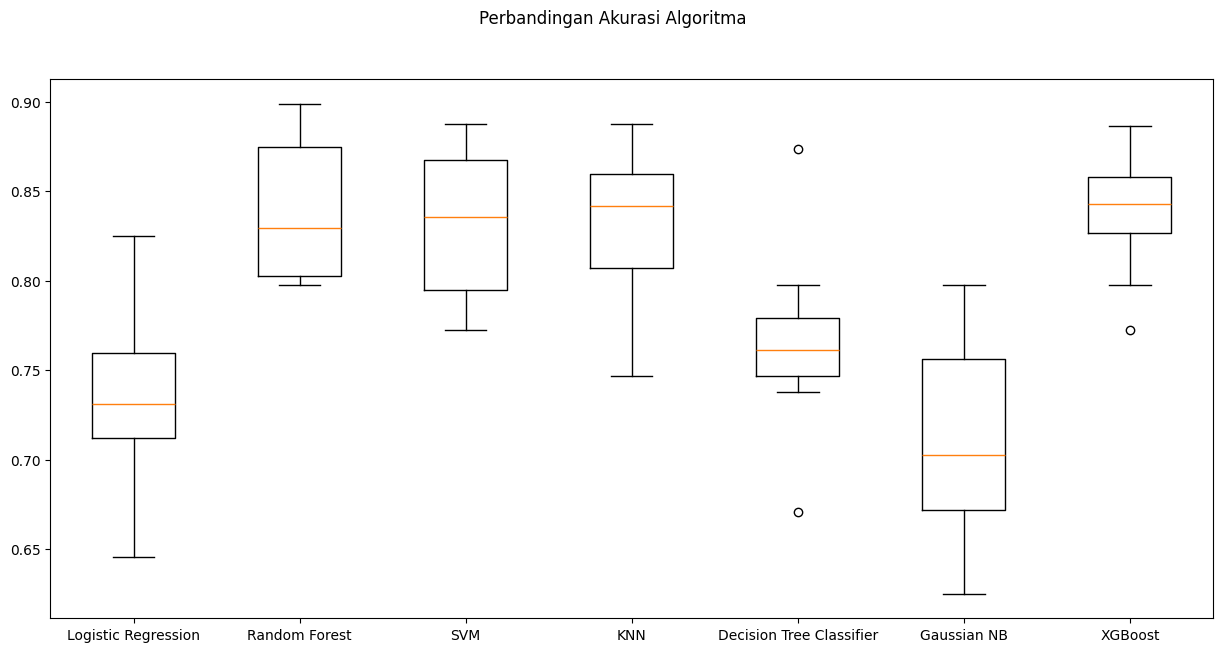

In [ ]:
# Membuat figure dengan ukuran yang disesuaikan
fig = plt.figure(figsize=(15, 7))
fig.suptitle('Perbandingan Akurasi Algoritma')  # Judul untuk figure

# Menambahkan subplot ke dalam figure
ax = fig.add_subplot(111)

# Membuat box plot untuk hasil akurasi
plt.boxplot(accuracy_scores)

# Mengatur label sumbu x dengan nama-nama model
ax.set_xticklabels(model_names)

# Menampilkan plot
plt.show()

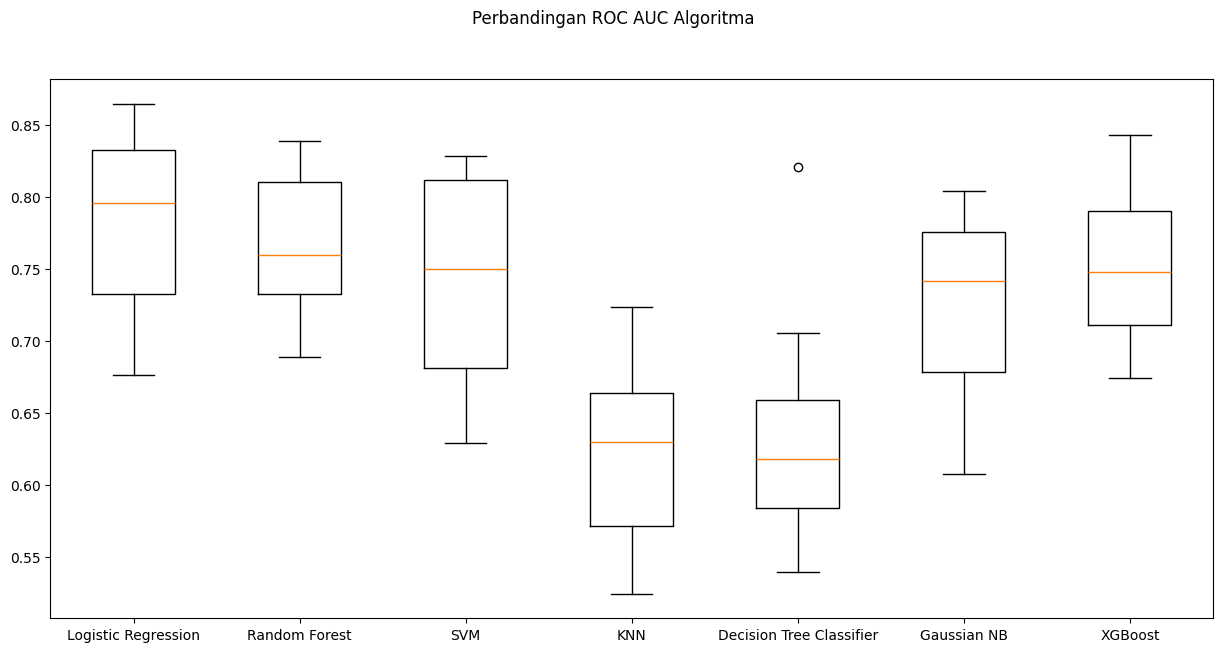

In [ ]:
# Membuat figure dengan ukuran yang disesuaikan
fig = plt.figure(figsize=(15, 7))
fig.suptitle('Perbandingan ROC AUC Algoritma')  # Judul untuk figure

# Menambahkan subplot ke dalam figure
ax = fig.add_subplot(111)

# Membuat box plot untuk hasil ROC AUC
plt.boxplot(roc_auc_scores)

# Mengatur label sumbu x dengan nama-nama model
ax.set_xticklabels(model_names)

# Menampilkan plot
plt.show()


Hyperparameter tuning untuk model terpilih (XGBoost)

In [2]:
import pandas as pd
df = pd.read_csv("employee_data_preprocessed.csv")
df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,2.261905,3.718683,1.785714,1.25,0.000000,0.0,2.214286,0.000000,1.25,1.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
1,3.928571,4.370079,0.535714,3.75,0.000000,5.0,0.285714,3.333333,0.00,3.333333,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0,0.0
2,2.857143,1.621331,4.464286,2.50,3.333333,0.0,3.357143,3.333333,3.75,1.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,0.0
3,2.619048,3.657838,0.000000,1.25,1.666667,5.0,1.928571,0.000000,1.25,5.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,0.0
4,4.404762,2.229778,0.178571,2.50,5.000000,5.0,3.428571,3.333333,5.00,0.000000,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0


In [5]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1058 non-null   float64
 1   DailyRate                          1058 non-null   float64
 2   DistanceFromHome                   1058 non-null   float64
 3   Education                          1058 non-null   float64
 4   EnvironmentSatisfaction            1058 non-null   float64
 5   Gender                             1058 non-null   float64
 6   HourlyRate                         1058 non-null   float64
 7   JobInvolvement                     1058 non-null   float64
 8   JobLevel                           1058 non-null   float64
 9   JobSatisfaction                    1058 non-null   float64
 10  MonthlyIncome                      1058 non-null   float64
 11  MonthlyRate                        1058 non-null   float

In [7]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1058 entries, 0 to 1057
Series name: MaritalStatus_Single
Non-Null Count  Dtype  
--------------  -----  
1058 non-null   float64
dtypes: float64(1)
memory usage: 8.4 KB


In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1058 non-null   float64
 1   DailyRate                          1058 non-null   float64
 2   DistanceFromHome                   1058 non-null   float64
 3   Education                          1058 non-null   float64
 4   EnvironmentSatisfaction            1058 non-null   float64
 5   Gender                             1058 non-null   float64
 6   HourlyRate                         1058 non-null   float64
 7   JobInvolvement                     1058 non-null   float64
 8   JobLevel                           1058 non-null   float64
 9   JobSatisfaction                    1058 non-null   float64
 10  MonthlyIncome                      1058 non-null   float64
 11  MonthlyRate                        1058 non-null   float

In [ ]:
# Membuat model XGBClassifier dengan scale_pos_weight untuk menangani ketidakseimbangan kelas
xgb_classifier = XGBClassifier(scale_pos_weight=1, random_state=7, use_label_encoder=False, eval_metric='logloss')

# Daftar nilai-nilai hyperparameter yang ingin dicoba selama pencarian grid
param_grid = {
    'n_estimators': [50, 75, 100, 125, 150, 175],           # Jumlah pohon dalam hutan
    'min_child_weight': [2, 4, 6, 8, 10],                   # Minimum sum of instance weight (hessian) needed in a child
    'gamma': [0, 0.1, 0.2, 0.3],                            # Minimum loss reduction required to make a further partition
    'max_depth': [5, 10, 15, 20, 25]                        # Kedalaman maksimum pohon
}

# GridSearchCV untuk mencari kombinasi hyperparameter terbaik berdasarkan skor ROC AUC
grid_obj = GridSearchCV(
    xgb_classifier,                  # Model yang akan dioptimalkan
    return_train_score=True,        # Menyertakan skor pelatihan dalam hasil
    param_grid=param_grid,          # Daftar parameter untuk dicari
    scoring='roc_auc',              # Skor yang digunakan untuk evaluasi
    cv=10                           # 10-fold cross-validation
)

# Melakukan pencarian grid untuk menemukan kombinasi parameter terbaik
grid_fit = grid_obj.fit(X_train, y_train)

# Mengambil model terbaik berdasarkan pencarian grid
xgb_opt = grid_fit.best_estimator_

# Mencetak hasil terbaik
print('='*20)
print("Best Estimator : ", grid_obj.best_estimator_)  # Model terbaik yang ditemukan
print("Best Params    : ", grid_obj.best_params_)    # Parameter terbaik yang digunakan
print("Best Score     : ", grid_obj.best_score_)     # Skor terbaik yang dicapai selama pencarian
print('='*20)




Best Estimator :  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=7, ...)
Best Params    :  {'gamma': 0.2, 'max_depth': 5, 'min_child_weight': 10, 'n_estimators': 50}
Best Score     :  0.7888827838827839


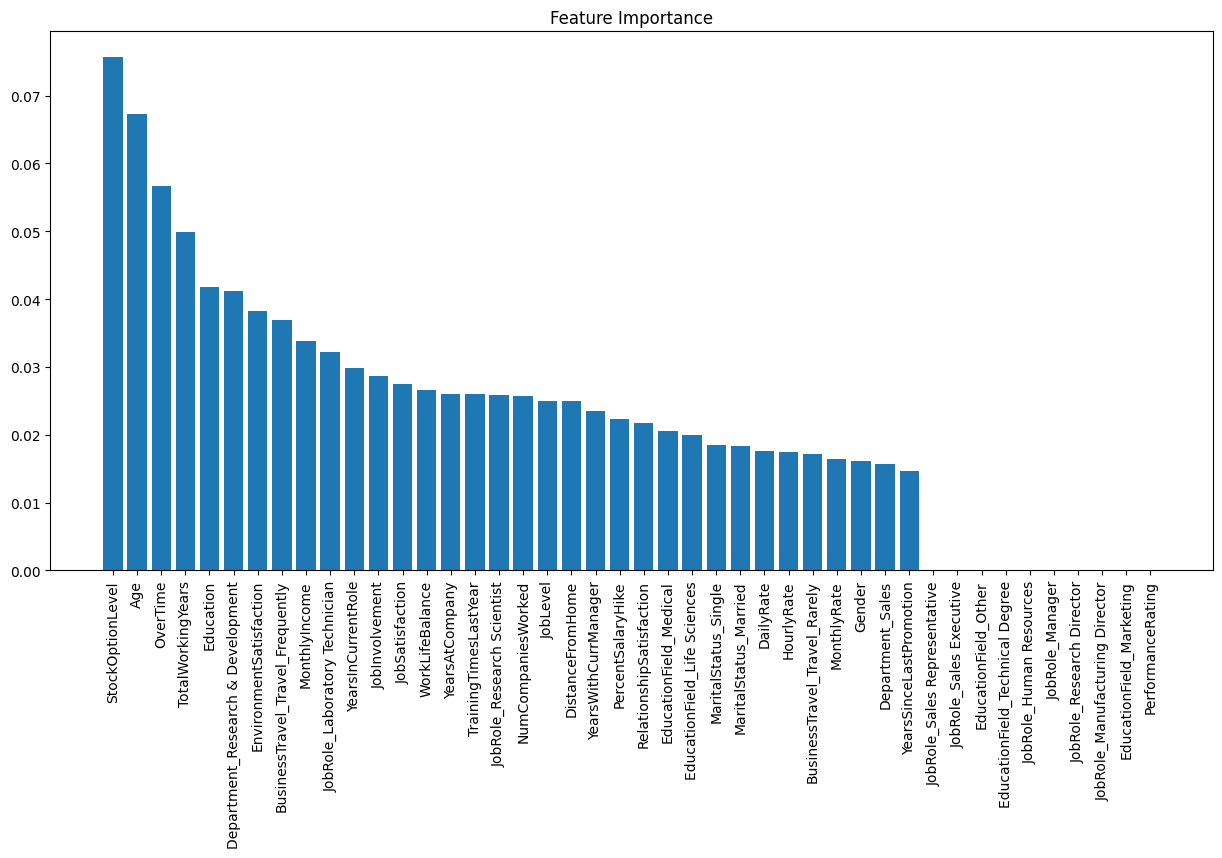

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=7, ...)

In [ ]:
# Menghitung kepentingan fitur berdasarkan model XGBoost yang dioptimalkan (xgb_opt)
importances = xgb_opt.feature_importances_

# Menyusun indeks fitur berdasarkan kepentingannya secara menurun
indices = np.argsort(importances)[::-1]

# Menyusun nama fitur agar sesuai dengan urutan kepentingannya
names = [X_train.columns[i] for i in indices]

# Membuat plot untuk menampilkan kepentingan fitur
plt.figure(figsize=(15, 7))  # Menentukan ukuran plot
plt.title("Feature Importance")  # Memberikan judul pada plot

# Menambahkan batang untuk setiap fitur berdasarkan kepentingannya
plt.bar(range(X_train.shape[1]), importances[indices])

# Menambahkan nama fitur pada label sumbu x, dan memutar nama fitur agar lebih mudah dibaca
plt.xticks(range(X_train.shape[1]), names, rotation=90)

# Menampilkan plot
plt.show()


xgb_opt.fit(X_train, y_train)

In [ ]:
# Mengambil nilai kepentingan fitur (feature importances) dari model XGBoost yang sudah dioptimalkan (xgb_opt)
importances = xgb_opt.feature_importances_

# Membuat DataFrame kosong untuk menyimpan nama fitur dan koefisien kepentingannya
df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])

# Mengisi DataFrame dengan nama fitur dan koefisien kepentingannya
for i in range(44):  # Menyesuaikan dengan jumlah fitur pada data (misalnya ada 44 fitur)
    feat = X_train.columns[i]  # Nama fitur di kolom X_train
    coeff = importances[i]  # Kepentingan (coefficient) dari fitur tersebut
    df_param_coeff.loc[i] = (feat, coeff)  # Menyimpan nama fitur dan koefisiennya di DataFrame

# Mengurutkan DataFrame berdasarkan kolom 'Coefficient' secara menurun
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)

# Mereset indeks DataFrame setelah pengurutan
df_param_coeff = df_param_coeff.reset_index(drop=True)

# Menampilkan 10 fitur teratas berdasarkan kepentingannya
df_param_coeff.head(10)

# Melatih model XGBoost yang sudah dioptimalkan menggunakan data latih (X_train, y_train)

,Feature,Coefficient
0,StockOptionLevel,0.075693
1,Age,0.067259
2,OverTime,0.056728
3,TotalWorkingYears,0.049868
4,Education,0.041730
5,Department_Research & Development,0.041165
6,EnvironmentSatisfaction,0.038311
7,BusinessTravel_Travel_Frequently,0.036974
8,MonthlyIncome,0.033785
9,JobRole_Laboratory Technician,0.032169


Hyperparameter tuning untuk model terpilih (Logistic Regression)


In [ ]:
# Menentukan k-fold cross-validation dengan 10 bagian, random state untuk reprodusibilitas, dan pengacakan data
kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)

# Inisialisasi model Logistic Regression dengan solver 'liblinear' dan penyesuaian untuk class imbalance
modelCV = LogisticRegression(solver='liblinear',
                             class_weight="balanced",  # Menyeimbangkan kelas
                             random_state=7)

# Menentukan skor yang akan dihitung, di sini kita menggunakan 'roc_auc' sebagai metric
scoring = 'roc_auc'

# Menjalankan cross-validation untuk mendapatkan AUC score
results = model_selection.cross_val_score(modelCV, X_train, y_train, cv=kfold, scoring=scoring)

# Menampilkan rata-rata AUC score dan standar deviasinya
print("AUC score (STD): %.2f (%.2f)" % (results.mean(), results.std()))


AUC score (STD): 0.78 (0.06)


In [ ]:
# Menentukan grid parameter untuk hyperparameter tuning
param_grid = {'C': np.arange(1e-03, 2, 0.01)}  # Rentang nilai C untuk regularisasi

# Membuat objek GridSearchCV dengan Logistic Regression dan parameter grid
log_gs = GridSearchCV(
    LogisticRegression(solver='liblinear', class_weight="balanced", random_state=7),
    return_train_score=True,    # Mengembalikan skor pelatihan selama pencarian grid
    param_grid=param_grid,      # Parameter grid untuk pencarian hyperparameter
    scoring='roc_auc',          # Menggunakan ROC AUC sebagai metrik evaluasi
    cv=10                       # 10-fold cross-validation
)

# Melatih model dengan pencarian grid pada data pelatihan
log_grid = log_gs.fit(X_train, y_train)

# Mendapatkan model terbaik dari pencarian grid
log_opt = log_grid.best_estimator_

# Mendapatkan hasil pencarian dari grid
results = log_gs.cv_results_

# Menampilkan hasil terbaik dari pencarian grid
print('='*20)
print("Best Estimator : ", log_gs.best_estimator_)   # Estimator terbaik yang ditemukan
print("Best Params    : ", log_gs.best_params_)      # Parameter terbaik yang ditemukan
print("Best Score     : ", log_gs.best_score_)       # Skor terbaik yang ditemukan
print('='*20)


Best Estimator :  LogisticRegression(C=np.float64(0.020999999999999998), class_weight='balanced',
                   random_state=7, solver='liblinear')
Best Params    :  {'C': np.float64(0.020999999999999998)}
Best Score     :  0.7964435564435565


In [ ]:
# Melatih model yang sudah dioptimalkan dengan data pelatihan
log_opt.fit(X_train, y_train)

LogisticRegression(C=np.float64(0.020999999999999998), class_weight='balanced',
                   random_state=7, solver='liblinear')

Hyperparameter tuning untuk model terpilih (Random Forest Classifier)


In [ ]:
# Membuat model RandomForestClassifier dengan class_weight 'balanced' untuk menangani ketidakseimbangan kelas
rf_classifier = RandomForestClassifier(class_weight="balanced", random_state=7)

# Daftar nilai-nilai hyperparameter yang ingin dicoba selama pencarian grid
param_grid = {
    'n_estimators': [50, 75, 100, 125, 150, 175],           # Jumlah pohon dalam hutan
    'min_samples_split': [2, 4, 6, 8, 10],                   # Minimum sampel yang diperlukan untuk membagi node internal
    'min_samples_leaf': [1, 2, 3, 4],                         # Minimum sampel yang diperlukan di daun
    'max_depth': [5, 10, 15, 20, 25]                          # Kedalaman maksimum pohon
}

# GridSearchCV untuk mencari kombinasi hyperparameter terbaik berdasarkan skor ROC AUC
grid_obj = GridSearchCV(
    rf_classifier,                    # Model yang akan dioptimalkan
    return_train_score=True,           # Menyertakan skor pelatihan dalam hasil
    param_grid=param_grid,             # Daftar parameter untuk dicari
    scoring='roc_auc',                 # Skor yang digunakan untuk evaluasi
    cv=10                              # 10-fold cross-validation
)

# Melakukan pencarian grid untuk menemukan kombinasi parameter terbaik
grid_fit = grid_obj.fit(X_train, y_train)

# Mengambil model terbaik berdasarkan pencarian grid
rf_opt = grid_fit.best_estimator_

# Mencetak hasil terbaik
print('='*20)
print("Best Estimator : ", grid_obj.best_estimator_)  # Model terbaik yang ditemukan
print("Best Params    : ", grid_obj.best_params_)    # Parameter terbaik yang digunakan
print("Best Score     : ", grid_obj.best_score_)     # Skor terbaik yang dicapai selama pencarian
print('='*20)


Best Estimator :  RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=3, random_state=7)
Best Params    :  {'max_depth': 15, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best Score     :  0.7797935397935397


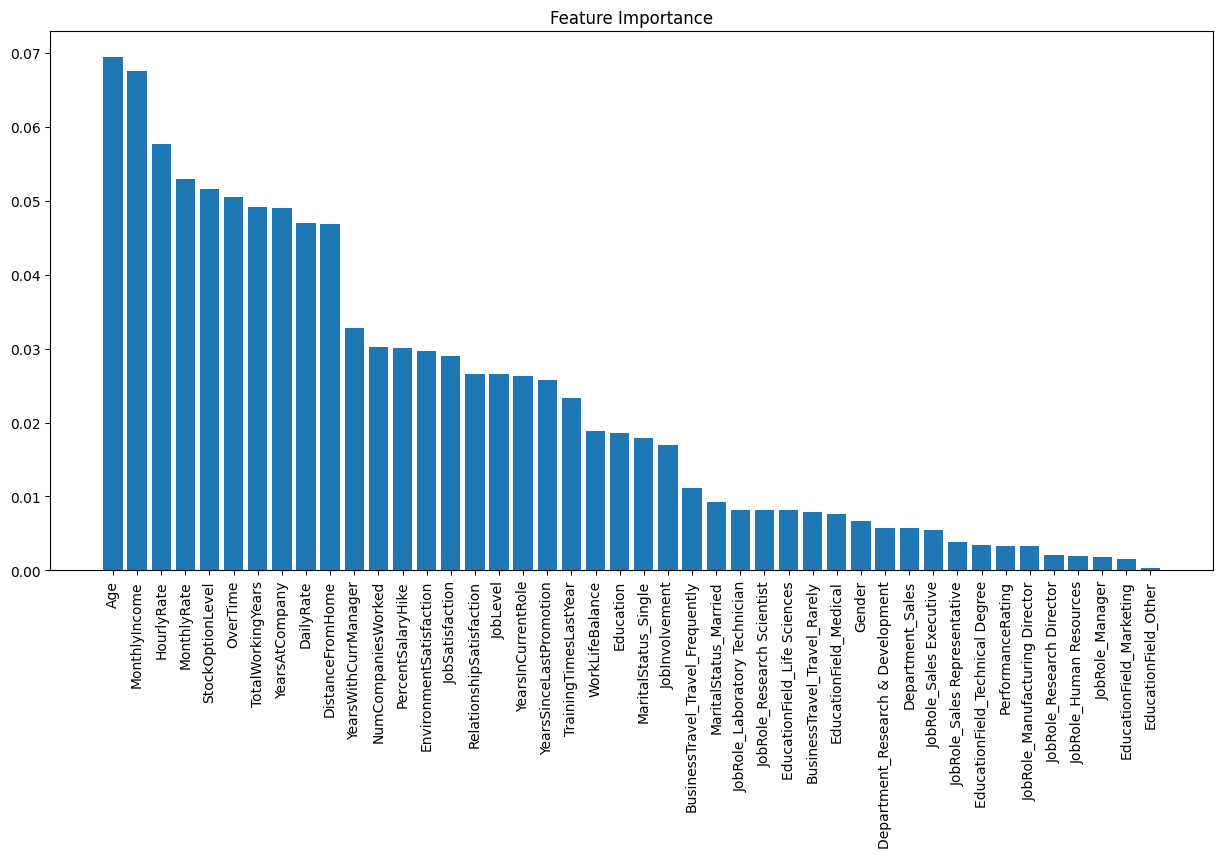

In [ ]:
# Menghitung kepentingan fitur berdasarkan model Random Forest yang dioptimalkan (rf_opt)
importances = rf_opt.feature_importances_

# Menyusun indeks fitur berdasarkan kepentingannya secara menurun
indices = np.argsort(importances)[::-1]

# Menyusun nama fitur agar sesuai dengan urutan kepentingannya
names = [X_train.columns[i] for i in indices]

# Membuat plot untuk menampilkan kepentingan fitur
plt.figure(figsize=(15, 7))  # Menentukan ukuran plot
plt.title("Feature Importance")  # Memberikan judul pada plot

# Menambahkan batang untuk setiap fitur berdasarkan kepentingannya
plt.bar(range(X_train.shape[1]), importances[indices])

# Menambahkan nama fitur pada label sumbu x, dan memutar nama fitur agar lebih mudah dibaca
plt.xticks(range(X_train.shape[1]), names, rotation=90)

# Menampilkan plot
plt.show()


In [ ]:
# Mengambil nilai kepentingan fitur (feature importances) dari model Random Forest yang sudah dioptimalkan (rf_opt)
importances = rf_opt.feature_importances_

# Membuat DataFrame kosong untuk menyimpan nama fitur dan koefisien kepentingannya
df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])

# Mengisi DataFrame dengan nama fitur dan koefisien kepentingannya
for i in range(44):  # Menyesuaikan dengan jumlah fitur pada data (misalnya ada 44 fitur)
    feat = X_train.columns[i]  # Nama fitur di kolom X_train
    coeff = importances[i]  # Kepentingan (coefficient) dari fitur tersebut
    df_param_coeff.loc[i] = (feat, coeff)  # Menyimpan nama fitur dan koefisiennya di DataFrame

# Mengurutkan DataFrame berdasarkan kolom 'Coefficient' secara menurun
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)

# Mereset indeks DataFrame setelah pengurutan
df_param_coeff = df_param_coeff.reset_index(drop=True)

# Menampilkan 10 fitur teratas berdasarkan kepentingannya
df_param_coeff.head(10)


,Feature,Coefficient
0,Age,0.069424
1,MonthlyIncome,0.067489
2,HourlyRate,0.057690
3,MonthlyRate,0.052894
4,StockOptionLevel,0.051594
5,OverTime,0.050554
6,TotalWorkingYears,0.049105
7,YearsAtCompany,0.049044
8,DailyRate,0.046949
9,DistanceFromHome,0.046783


In [ ]:
# Melatih model RandomForest yang sudah dioptimalkan menggunakan data latih (X_train, y_train)
rf_opt.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=3, random_state=7)

## Evaluation

### Evaluation XGBoost

Text(0.5, 427.9555555555555, 'Predicted label')

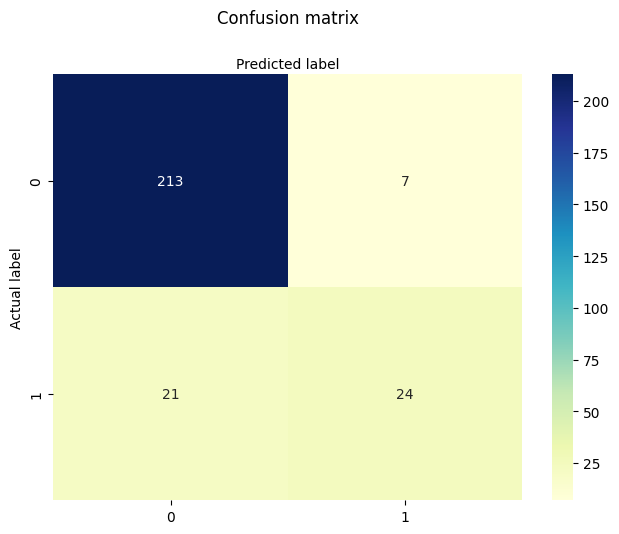

In [ ]:
# Menghitung confusion matrix antara prediksi dan data uji
cnf_matrix = metrics.confusion_matrix(y_test, xgb_opt.predict(X_test))

# Menyebutkan nama kelas untuk label
class_names = [0, 1]  # 0 untuk tidak mengalami attrition, 1 untuk mengalami attrition

# Membuat figure dan axis untuk plot
fig, ax = plt.subplots()

# Menentukan posisi tick marks pada sumbu X dan Y
tick_marks = np.arange(len(class_names))

# Mengatur label untuk sumbu X dan Y
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Membuat heatmap dari confusion matrix
sns.heatmap(
    pd.DataFrame(cnf_matrix),     # Data confusion matrix
    annot=True,                    # Menambahkan nilai pada setiap kotak
    cmap="YlGnBu",                 # Warna heatmap
    fmt='g'                        # Format nilai yang ditampilkan (g untuk integer)
)

# Menyesuaikan posisi label sumbu X agar berada di bagian atas
ax.xaxis.set_label_position("top")

# Menyesuaikan layout agar tidak terpotong
plt.tight_layout()

# Menambahkan judul untuk confusion matrix
plt.title('Confusion matrix', y=1.1)

# Menambahkan label pada sumbu Y dan X
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [ ]:
# Menampilkan akurasi model Logistic Regression yang sudah dioptimalkan pada data uji (test set)
print('Akurasi dari Logistic Regression Classifier pada set test: {:.2f}'.format(xgb_opt.score(X_test, y_test)*100))


Akurasi dari Logistic Regression Classifier pada set test: 89.43


In [ ]:
# Melatih model dengan data pelatihan
xgb_opt.fit(X_train, y_train)

# Menampilkan classification report untuk model Logistic Regression yang dioptimalkan pada data uji
print(classification_report(y_test, xgb_opt.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94       220
         1.0       0.77      0.53      0.63        45

    accuracy                           0.89       265
   macro avg       0.84      0.75      0.78       265
weighted avg       0.89      0.89      0.89       265



In [ ]:
# Memprediksi probabilitas untuk setiap kelas, mengembalikan probabilitas untuk kedua kelas (0 dan 1)
probs = xgb_opt.predict_proba(X_test)

# Mengambil hanya probabilitas untuk kelas 1 (karyawan yang keluar/Attrition)
probs = probs[:, 1]

# Menghitung nilai AUC (Area Under the Curve) menggunakan probabilitas untuk kelas 1
xgb_opt_roc_auc = roc_auc_score(y_test, probs)

# Mencetak AUC score
print('AUC score: %.3f' % xgb_opt_roc_auc)


AUC score: 0.853


### Evaluation Logistic Regression

Text(0.5, 427.9555555555555, 'Predicted label')

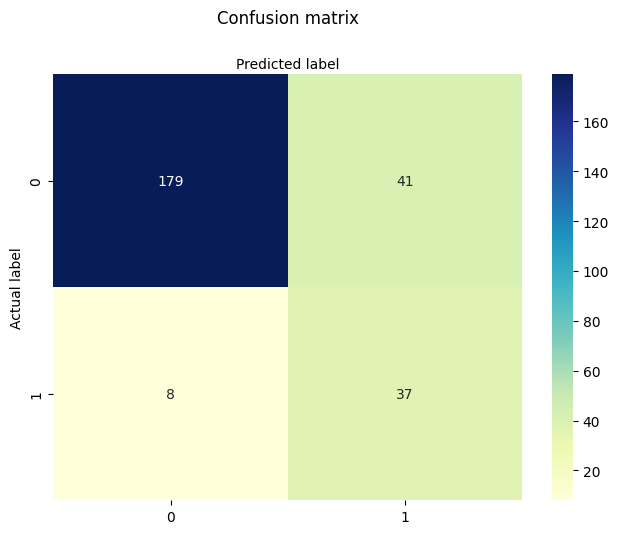

In [ ]:
# Menghitung confusion matrix antara prediksi dan data uji
cnf_matrix = metrics.confusion_matrix(y_test, log_opt.predict(X_test))

# Menyebutkan nama kelas untuk label
class_names = [0, 1]  # 0 untuk tidak mengalami attrition, 1 untuk mengalami attrition

# Membuat figure dan axis untuk plot
fig, ax = plt.subplots()

# Menentukan posisi tick marks pada sumbu X dan Y
tick_marks = np.arange(len(class_names))

# Mengatur label untuk sumbu X dan Y
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Membuat heatmap dari confusion matrix
sns.heatmap(
    pd.DataFrame(cnf_matrix),     # Data confusion matrix
    annot=True,                    # Menambahkan nilai pada setiap kotak
    cmap="YlGnBu",                 # Warna heatmap
    fmt='g'                        # Format nilai yang ditampilkan (g untuk integer)
)

# Menyesuaikan posisi label sumbu X agar berada di bagian atas
ax.xaxis.set_label_position("top")

# Menyesuaikan layout agar tidak terpotong
plt.tight_layout()

# Menambahkan judul untuk confusion matrix
plt.title('Confusion matrix', y=1.1)

# Menambahkan label pada sumbu Y dan X
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [ ]:
# Menampilkan akurasi model Logistic Regression yang sudah dioptimalkan pada data uji (test set)
print('Akurasi dari Logistic Regression Classifier pada set test: {:.2f}'.format(log_opt.score(X_test, y_test)*100))


Akurasi dari Logistic Regression Classifier pada set test: 81.51


In [ ]:
# Melatih model dengan data pelatihan
log_opt.fit(X_train, y_train)

# Menampilkan classification report untuk model Logistic Regression yang dioptimalkan pada data uji
print(classification_report(y_test, log_opt.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.96      0.81      0.88       220
         1.0       0.47      0.82      0.60        45

    accuracy                           0.82       265
   macro avg       0.72      0.82      0.74       265
weighted avg       0.88      0.82      0.83       265



In [ ]:
# Memprediksi probabilitas untuk setiap kelas, mengembalikan probabilitas untuk kedua kelas (0 dan 1)
probs = log_opt.predict_proba(X_test)

# Mengambil hanya probabilitas untuk kelas 1 (karyawan yang keluar/Attrition)
probs = probs[:, 1]

# Menghitung nilai AUC (Area Under the Curve) menggunakan probabilitas untuk kelas 1
logit_roc_auc = roc_auc_score(y_test, probs)

# Mencetak AUC score
print('AUC score: %.3f' % logit_roc_auc)


AUC score: 0.885


### Evaluation Random Forest Classifier

Text(0.5, 427.9555555555555, 'Predicted label')

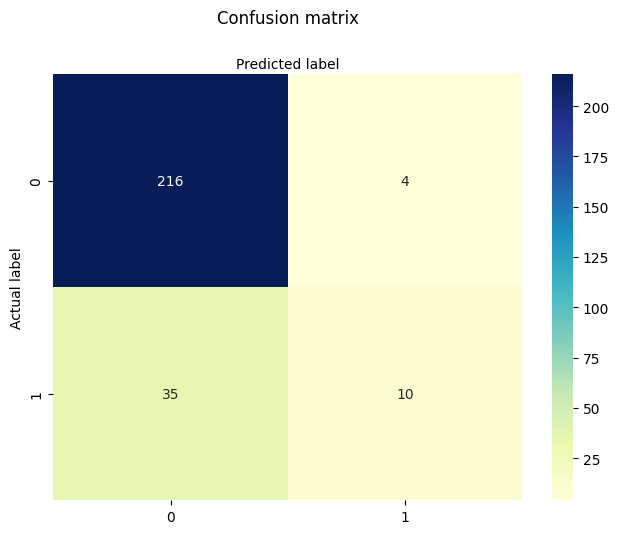

In [ ]:
# Membuat confusion matrix untuk model Random Forest yang sudah dioptimalkan (rf_opt)
cnf_matrix = metrics.confusion_matrix(y_test, rf_opt.predict(X_test))

# Mendefinisikan nama kelas
class_names = [0, 1]  # 0: tidak keluar, 1: keluar

# Membuat figure dan axis untuk plot
fig, ax = plt.subplots()

# Menentukan posisi label untuk sumbu x dan y
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)  # Menandai sumbu x dengan nama kelas
plt.yticks(tick_marks, class_names)  # Menandai sumbu y dengan nama kelas

# Membuat heatmap untuk confusion matrix
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')

# Menyesuaikan posisi label sumbu x agar berada di atas
ax.xaxis.set_label_position("top")

# Mengatur layout agar rapi
plt.tight_layout()

# Menambahkan judul pada plot
plt.title('Confusion matrix', y=1.1)

# Menambahkan label pada sumbu y dan x
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [ ]:
print('Akurasi dari RandomForest Regression Classifier pada set test: {:.2f}'.format(rf_opt.score(X_test, y_test)*100))

Akurasi dari RandomForest Regression Classifier pada set test: 85.28


In [ ]:
# Classification report untuk RF Regression setelah di optimisasi
rf_opt.fit(X_train, y_train)
print(classification_report(y_test, rf_opt.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92       220
         1.0       0.71      0.22      0.34        45

    accuracy                           0.85       265
   macro avg       0.79      0.60      0.63       265
weighted avg       0.84      0.85      0.82       265



In [ ]:
# Memprediksi probabilitas untuk data uji (X_test)
probs = rf_opt.predict_proba(X_test)  # Mengambil probabilitas untuk setiap kelas
probs = probs[:, 1]  # Menyimpan hanya probabilitas yang berhubungan dengan karyawan yang keluar (Attrition = 1)

# Menghitung nilai AUC (Area Under the Curve) menggunakan skor dari data uji
rf_opt_roc_auc = roc_auc_score(y_test, probs)

# Menampilkan nilai AUC dengan 3 digit setelah koma
print('AUC score: %.3f' % rf_opt_roc_auc)

AUC score: 0.859


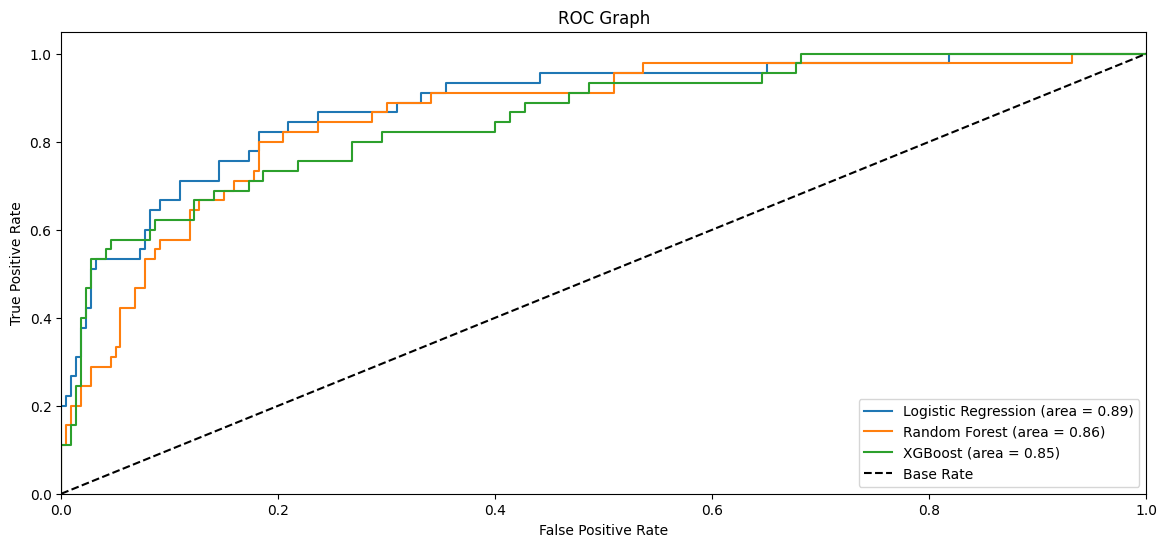

In [ ]:
# Membuat ROC Graph untuk membandingkan model Logistic Regression, Random Forest, dan XGBoost

# Menghitung False Positive Rate (fpr), True Positive Rate (tpr), dan thresholds untuk model Logistic Regression
fpr, tpr, thresholds = roc_curve(y_test, log_opt.predict_proba(X_test)[:, 1])

# Menghitung False Positive Rate (fpr), True Positive Rate (tpr), dan thresholds untuk model Random Forest
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_opt.predict_proba(X_test)[:, 1])

# Menghitung False Positive Rate (fpr), True Positive Rate (tpr), dan thresholds untuk model XGBoost
xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_test, xgb_opt.predict_proba(X_test)[:, 1])

# Membuat figure dengan ukuran 14x6 inci
plt.figure(figsize=(14, 6))

# Plot ROC curve untuk Logistic Regression
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)

# Plot ROC curve untuk Random Forest
plt.plot(rf_fpr, rf_tpr, label='Random Forest (area = %0.2f)' % rf_opt_roc_auc)

# Plot ROC curve untuk XGBoost
plt.plot(xgb_fpr, xgb_tpr, label='XGBoost (area = %0.2f)' % xgb_opt_roc_auc)

# Plot Base Rate (diagonal yang menggambarkan kinerja model yang acak)
plt.plot([0, 1], [0, 1], label='Base Rate', color='k', linestyle='--')

# Mengatur batasan sumbu X dan Y
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Memberikan label pada sumbu
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Memberikan judul pada grafik
plt.title('ROC Graph')

# Menampilkan legenda di pojok kanan bawah
plt.legend(loc="lower right")

# Menampilkan grafik
plt.show()


In [ ]:
# Bandingkan AUC ketiga model: rf_opt, log_opt, xgb_opt

# Buat dictionary untuk menyimpan AUC dari masing-masing model
model_auc_scores = {
    'RandomForest': rf_opt_roc_auc,
    'LogisticRegression': logit_roc_auc,
    'XGBoost': xgb_opt_roc_auc
}

# Ambil model dengan AUC tertinggi
model_name = max(model_auc_scores, key=model_auc_scores.get)
best_auc = model_auc_scores[model_name]

# Tentukan model terbaik berdasarkan nama
if model_name == "RandomForest":
    best_model = rf_opt
elif model_name == "LogisticRegression":
    best_model = log_opt
else:
    best_model = xgb_opt

# Simpan model terbaik ke file
filename = f'{model_name}_best_model.pkl'
joblib.dump(best_model, filename)

print(f'Model terbaik: {model_name} dengan AUC: {best_auc:.3f}')
print(f'Model telah disimpan sebagai {filename}')

Model terbaik: LogisticRegression dengan AUC: 0.885
Model telah disimpan sebagai LogisticRegression_best_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>